In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [12]:
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [13]:
file_path = '/heart_Desease.csv.xlsx'
df = pd.read_excel(file_path)

In [14]:
df = df.drop_duplicates()

In [51]:
df.replace('?', np.nan, inplace=True)
df = df.apply(pd.to_numeric, errors='coerce')
df.fillna(df.mean(numeric_only=True), inplace=True)
print("Data cleaned. Shape after cleaning:", df.shape)

Data cleaned. Shape after cleaning: (302, 15)


In [16]:
df = df.dropna()

In [17]:
df = df.convert_dtypes()

In [50]:
df.to_excel('/heart_cleaned.xlsx', index=False)

In [19]:
print(df.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


In [20]:
print(df.tail())

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
723   68    0   2       120   211    0        0      115      0      1.5   
733   44    0   2       108   141    0        1      175      0      0.6   
739   52    1   0       128   255    0        1      161      1      0.0   
843   59    1   3       160   273    0        0      125      0      0.0   
878   54    1   0       120   188    0        1      113      0      1.4   

     slope  ca  thal  target  
723      1   0     2       1  
733      1   0     2       1  
739      2   1     3       0  
843      2   0     2       0  
878      1   1     3       0  


In [21]:
df.at[5, 'bp'] = pd.NA

In [22]:
df.loc[df['bp'] < 0, 'bp'] = pd.NA

In [23]:
df.loc[df['bp'] < 0, 'bp'] = pd.NA

In [24]:
print(df.to_string())

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  ca  thal  target    bp
0     52    1   0       125   212    0        1      168      0      1.0      2   2     3       0   NaN
1     53    1   0       140   203    1        0      155      1      3.1      0   0     3       0   NaN
2     70    1   0       145   174    0        1      125      1      2.6      0   0     3       0   NaN
3     61    1   0       148   203    0        1      161      0      0.0      2   1     3       0   NaN
4     62    0   0       138   294    1        1      106      0      1.9      1   3     2       0   NaN
5     58    0   0       100   248    0        0      122      0      1.0      1   0     2       1  <NA>
6     58    1   0       114   318    0        2      140      0      4.4      0   3     1       0   NaN
7     55    1   0       160   289    0        0      145      1      0.8      1   1     3       0   NaN
8     46    1   0       120   249    0        0      144      0 

In [25]:
df.fillna(120, inplace = True)

<ipython-input-25-c7a1cda7613d>:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(120, inplace = True)


In [26]:
df.loc[(df['bp'] <= 0), 'bp'] = pd.NA

In [27]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 878
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    Int64  
 1   sex       302 non-null    Int64  
 2   cp        302 non-null    Int64  
 3   trestbps  302 non-null    Int64  
 4   chol      302 non-null    Int64  
 5   fbs       302 non-null    Int64  
 6   restecg   302 non-null    Int64  
 7   thalach   302 non-null    Int64  
 8   exang     302 non-null    Int64  
 9   oldpeak   302 non-null    Float64
 10  slope     302 non-null    Int64  
 11  ca        302 non-null    Int64  
 12  thal      302 non-null    Int64  
 13  target    302 non-null    Int64  
 14  bp        302 non-null    float64
dtypes: Float64(1), Int64(13), float64(1)
memory usage: 50.0 KB
None


In [28]:
X = df.drop('target', axis=1)
y = df['target']

In [29]:
X = np.array(X)
y = np.array(y)

In [65]:
y_pred = model.predict(X_test)

In [66]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [67]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [33]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[23  9]
 [ 3 26]]


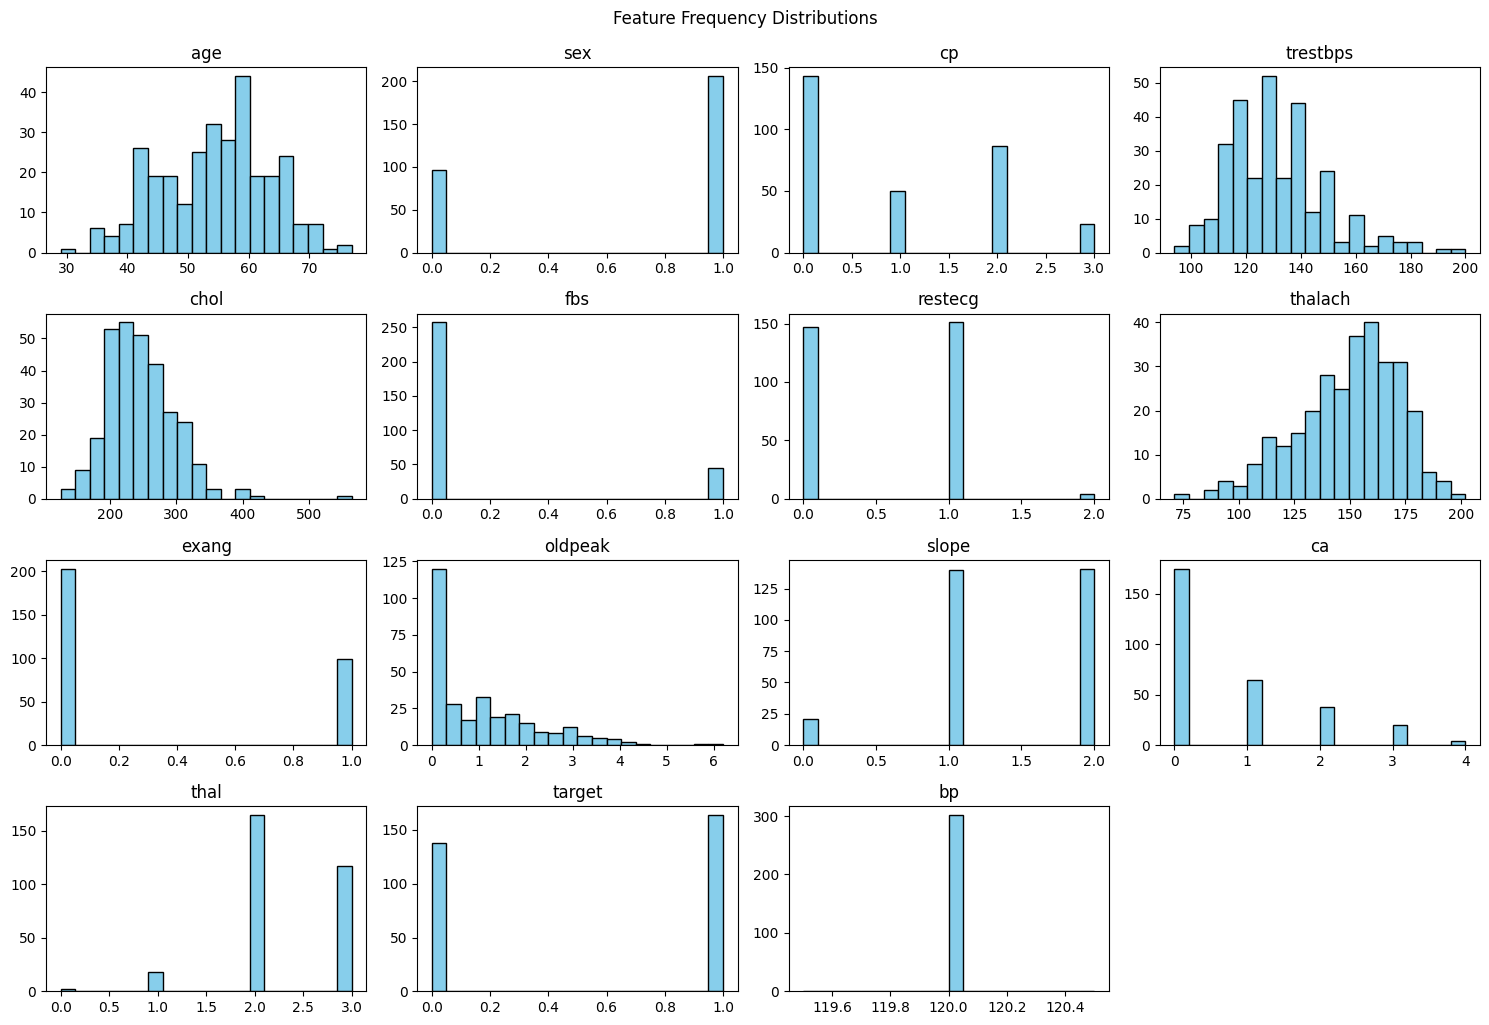

In [34]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(df.columns):
    plt.subplot(4, 4, i+1)
    plt.hist(df[col], bins=20, color='skyblue', edgecolor='black')
    plt.title(col)
    plt.tight_layout()
plt.suptitle('Feature Frequency Distributions', y=1.02)
plt.show()

In [60]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [61]:
X = df.select_dtypes(include=['int64', 'float64'])

In [62]:
X_cols = X.columns

In [63]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [64]:
X_scaled_df = pd.DataFrame(X_scaled, columns=X_cols)
X_scaled_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,bp
0,-0.267966,0.682656,-0.935208,-0.376556,-0.667728,-0.418446,0.901657,0.806035,-0.698344,-0.037124,0.979514,1.274980,1.119967,-1.09014,0.0
1,-0.157260,0.682656,-0.935208,0.478910,-0.841918,2.389793,-1.002541,0.237495,1.431958,1.773958,-2.271182,-0.714911,1.119967,-1.09014,0.0
2,1.724733,0.682656,-0.935208,0.764066,-1.403197,-0.418446,0.901657,-1.074521,1.431958,1.342748,-2.271182,-0.714911,1.119967,-1.09014,0.0
3,0.728383,0.682656,-0.935208,0.935159,-0.841918,-0.418446,0.901657,0.499898,-0.698344,-0.899544,0.979514,0.280034,1.119967,-1.09014,0.0
4,0.839089,-1.464866,-0.935208,0.364848,0.919336,2.389793,0.901657,-1.905464,-0.698344,0.739054,-0.645834,2.269926,-0.513994,-1.09014,0.0


In [55]:
X = df.drop('target', axis=1)
y = df['target']

In [56]:
X = X.convert_dtypes()
X = np.array(X)
X = scaler.fit_transform(X)

In [57]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=3217)

In [68]:
from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
print("Naive Bayes model trained")

Naive Bayes model trained


In [40]:
from sklearn.metrics import confusion_matrix, accuracy_score
y_pred = nb_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[24  5]
 [ 6 26]]


In [41]:
train_accuracy = accuracy_score(y_train, nb_model.predict(X_train))
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Train Accuracy: 0.8506
Test Accuracy: 0.8197


In [42]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(GaussianNB(), X, y, cv=10, scoring='accuracy')
print(f"10-Fold CV Accuracy: {cv_scores.mean():.4f}")

10-Fold CV Accuracy: 0.8143


In [43]:
y_pred = nb_model.predict(X_test)

In [44]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred)

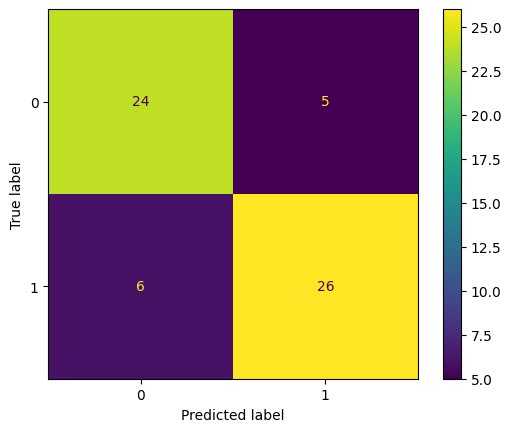

In [45]:
from sklearn.model_selection import cross_val_score
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=[0, 1])
cm_display.plot()
plt.show()